In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
sample_list="/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/plots/sample_list.txt"

sample_df = pd.read_csv(sample_list, sep=',')
sample_df

,File,Tissue,Sample
0,PS30385.m84046_250330_043334_s2.bc2065.ft,BRAIN_CEREBELLUM,SMHT001
1,PS30385.m84046_250413_105801_s4.bc2065.ft,BRAIN_CEREBELLUM,SMHT001
2,PS30385.m84046_250427_122844_s1.bc2065.ft,BRAIN_CEREBELLUM,SMHT001
3,PS30385.m84046_250427_143148_s2.bc2065.ft,BRAIN_CEREBELLUM,SMHT001
4,PS30394.m84046_250330_043334_s2.bc2068.ft,AORTA_ABD,SMHT001
...,...,...,...
72,PS30475.m84046_250506_011348_s4.bc2071.ft,LADRENAL,SMHT024
73,PS30451.m84046_250713_081450_s2.bc2030.ft,ESOPHAGUS,SMHT024
74,PS30451.m84046_250715_001222_s3.bc2030.ft,ESOPHAGUS,SMHT024
75,PS30463.m84046_250713_081450_s2.bc2029.ft,COLON-DESC,SMHT024


In [ ]:
merged_df = None


for index, row in sample_df.iterrows():
    sample = row['Sample']
    file = row['File']
    file_path=f"/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/{sample}/output/pb-fiberseq/{file}/mitoscope/qc/{file}.minimod.tsv"

    df = pd.read_csv(file_path, sep='\t').sort_values(['contig','start'])
    
    df = df[['contig', 'start', 'end', file]]

    if merged_df is None:
        merged_df = df
    else:
        merged_df = pd.merge(merged_df, df, on=['contig','start', 'end'], how='outer') 


merged_df = merged_df.sort_values(['contig','start'])
merged_df['index'] = range(0, len(merged_df))

merged_df


/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/SMHT001/output/pb-fiberseq/PS30385.m84046_250330_043334_s2.bc2065.ft/mitoscope/qc/PS30385.m84046_250330_043334_s2.bc2065.ft.minimod.tsv
/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/SMHT001/output/pb-fiberseq/PS30385.m84046_250413_105801_s4.bc2065.ft/mitoscope/qc/PS30385.m84046_250413_105801_s4.bc2065.ft.minimod.tsv
/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/SMHT001/output/pb-fiberseq/PS30385.m84046_250427_122844_s1.bc2065.ft/mitoscope/qc/PS30385.m84046_250427_122844_s1.bc2065.ft.minimod.tsv
/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/SMHT001/output/pb-fiberseq/PS30385.m84046_250427_143148_s2.bc2065.ft/mitoscope/qc/PS30385.m84046_250427_143148_s2.bc2065.ft.minimod.tsv
/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/SMHT001/output/pb-fiberseq/PS30394.m84046_250330_043334_s2.bc2068.ft/mitoscope/qc/PS30394.m84046_250330_043334_s2.bc2068.ft.minimod.tsv
/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/SMHT001/output/pb-fiberseq/PS30394.m84046_25

In [2]:
df = pd.read_csv("/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/SMHT001/output/multisample_output/merged.qc_summary.txt", sep='\t')
df

,Sample,Read_Count,Mean_Coverage,Average_Read_Length,N50,Average_Methylation_Percent,Num_Meth_Sites_GT_1,Num_Meth_Sites_GT_5,Num_Meth_Sites_GT_10
0,PS30284.m84046_250525_075910_s3.bc2030.ft,1327,707.64,16455.00,16566,0.036529,0.958430,0.192841,0.019630
1,PS30284.m84046_250525_100214_s4.bc2030.ft,1337,708.72,16389.20,16566,0.036279,0.946882,0.182448,0.026559
2,PS30385.m84046_250330_043334_s2.bc2065.ft,7203,1788.92,5551.52,5668,0.047405,0.952656,0.302540,0.093534
3,PS30385.m84046_250413_105801_s4.bc2065.ft,6513,2704.65,11637.40,11803,0.046104,0.968822,0.300231,0.087760
4,PS30385.m84046_250427_122844_s1.bc2065.ft,6413,2654.10,11579.20,11660,0.046573,0.967667,0.294457,0.093534
5,PS30385.m84046_250427_143148_s2.bc2065.ft,6315,2610.00,11584.70,11682,0.048323,0.976905,0.303695,0.098152
6,PS30394.m84046_250330_043334_s2.bc2068.ft,2496,532.52,4436.28,4421,0.066519,0.839492,0.370670,0.209007
7,PS30394.m84046_250413_085446_s3.bc2068.ft,304,116.34,9397.88,9437,0.062214,0.766744,0.366051,0.193995
8,PS30394.m84046_250427_102543_s4.bc2068.ft,408,147.55,9297.60,9465,0.065775,0.815242,0.406467,0.211316


In [3]:
meta = pd.read_csv("/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/SMHT001/SMHT001-metadata.csv")
meta

,Sample,Tissue
0,PS30385.m84046_250330_043334_s2.bc2065.ft,SMHT001-BRAIN_CEREBELLUM
1,PS30385.m84046_250413_105801_s4.bc2065.ft,SMHT001-BRAIN_CEREBELLUM
2,PS30385.m84046_250427_122844_s1.bc2065.ft,SMHT001-BRAIN_CEREBELLUM
3,PS30385.m84046_250427_143148_s2.bc2065.ft,SMHT001-BRAIN_CEREBELLUM
4,PS30394.m84046_250330_043334_s2.bc2068.ft,SMHT001_AORTA_ABD
5,PS30394.m84046_250413_085446_s3.bc2068.ft,SMHT001_AORTA_ABD
6,PS30394.m84046_250427_102543_s4.bc2068.ft,SMHT001_AORTA_ABD
7,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD
8,PS30284.m84046_250525_100214_s4.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD


In [4]:
qc_df = pd.merge(df, meta, on="Sample", how="inner")
qc_df['PS_ID'] = qc_df['Sample'].str.split('.').str[0]

qc_df

,Sample,Read_Count,Mean_Coverage,Average_Read_Length,N50,Average_Methylation_Percent,Num_Meth_Sites_GT_1,Num_Meth_Sites_GT_5,Num_Meth_Sites_GT_10,Tissue,PS_ID
0,PS30284.m84046_250525_075910_s3.bc2030.ft,1327,707.64,16455.00,16566,0.036529,0.958430,0.192841,0.019630,SMHT001_FIBROBLASTS_PACBIOSTD,PS30284
1,PS30284.m84046_250525_100214_s4.bc2030.ft,1337,708.72,16389.20,16566,0.036279,0.946882,0.182448,0.026559,SMHT001_FIBROBLASTS_PACBIOSTD,PS30284
2,PS30385.m84046_250330_043334_s2.bc2065.ft,7203,1788.92,5551.52,5668,0.047405,0.952656,0.302540,0.093534,SMHT001-BRAIN_CEREBELLUM,PS30385
3,PS30385.m84046_250413_105801_s4.bc2065.ft,6513,2704.65,11637.40,11803,0.046104,0.968822,0.300231,0.087760,SMHT001-BRAIN_CEREBELLUM,PS30385
4,PS30385.m84046_250427_122844_s1.bc2065.ft,6413,2654.10,11579.20,11660,0.046573,0.967667,0.294457,0.093534,SMHT001-BRAIN_CEREBELLUM,PS30385
5,PS30385.m84046_250427_143148_s2.bc2065.ft,6315,2610.00,11584.70,11682,0.048323,0.976905,0.303695,0.098152,SMHT001-BRAIN_CEREBELLUM,PS30385
6,PS30394.m84046_250330_043334_s2.bc2068.ft,2496,532.52,4436.28,4421,0.066519,0.839492,0.370670,0.209007,SMHT001_AORTA_ABD,PS30394
7,PS30394.m84046_250413_085446_s3.bc2068.ft,304,116.34,9397.88,9437,0.062214,0.766744,0.366051,0.193995,SMHT001_AORTA_ABD,PS30394
8,PS30394.m84046_250427_102543_s4.bc2068.ft,408,147.55,9297.60,9465,0.065775,0.815242,0.406467,0.211316,SMHT001_AORTA_ABD,PS30394


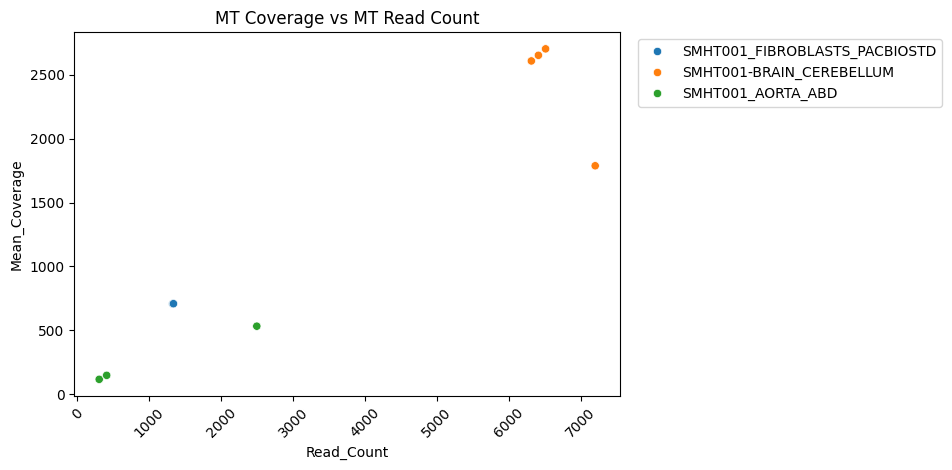

In [5]:
sns.scatterplot(data=qc_df, x='Read_Count', y='Mean_Coverage', hue='Tissue', alpha=1)
    
plt.xticks(rotation=45)
plt.title('MT Coverage vs MT Read Count')
plt.tight_layout()
#plt.yscale('log')
#plt.xscale('log')
#plt.xlim(-100,6000)
#plt.ylim(-100,3000)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.show()


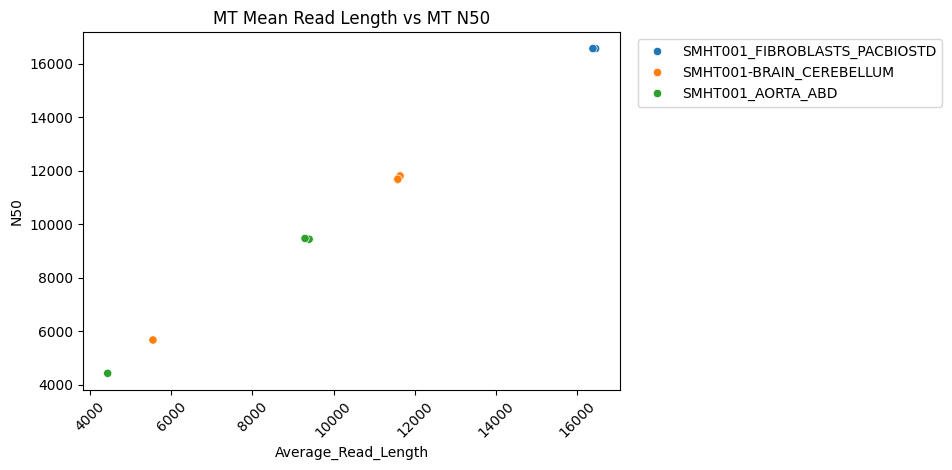

In [6]:
sns.scatterplot(data=qc_df, x='Average_Read_Length', y='N50', hue='Tissue', alpha=1)
    
plt.xticks(rotation=45)
plt.title('MT Mean Read Length vs MT N50')
plt.tight_layout()
#plt.yscale('log')
#plt.xscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.show()

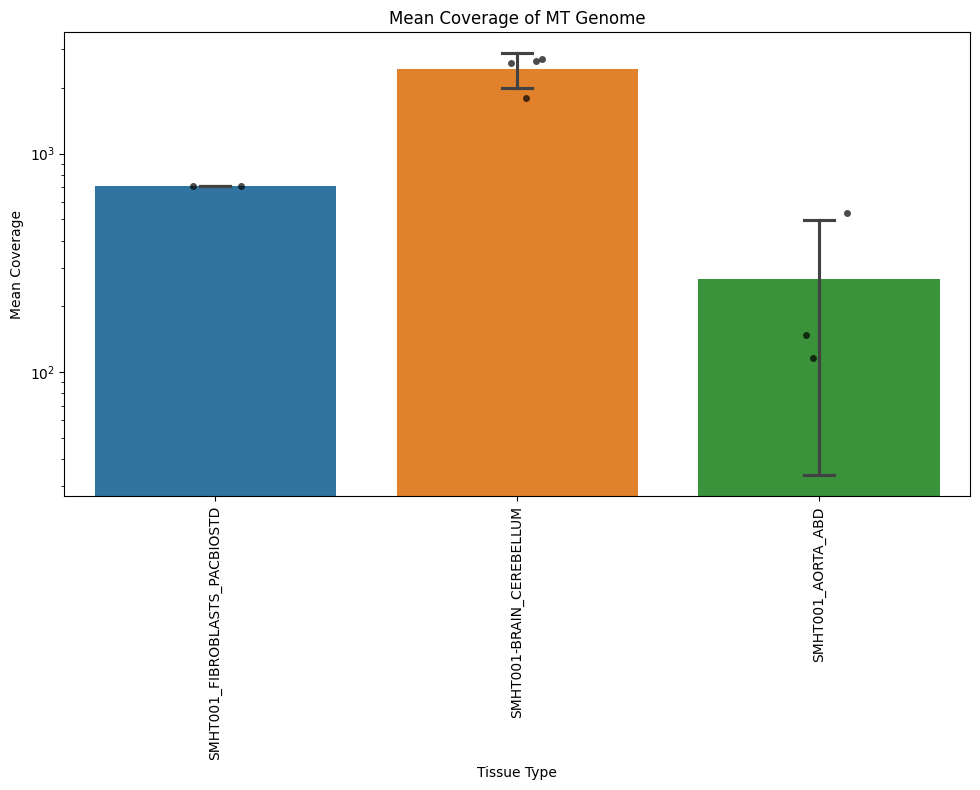

In [7]:

plt.figure(figsize=(10, 8))

sns.barplot(data=qc_df, x='Tissue', y='Mean_Coverage', errorbar='sd', hue='Tissue', capsize=0.1)
sns.stripplot(data=qc_df, x='Tissue', y='Mean_Coverage', color='black', jitter=True, alpha=0.7)

plt.title('Mean Coverage of MT Genome')
plt.xlabel('Tissue Type')
plt.ylabel('Mean Coverage')
plt.xticks(rotation=90)
plt.tight_layout()
plt.yscale('log')
plt.show()

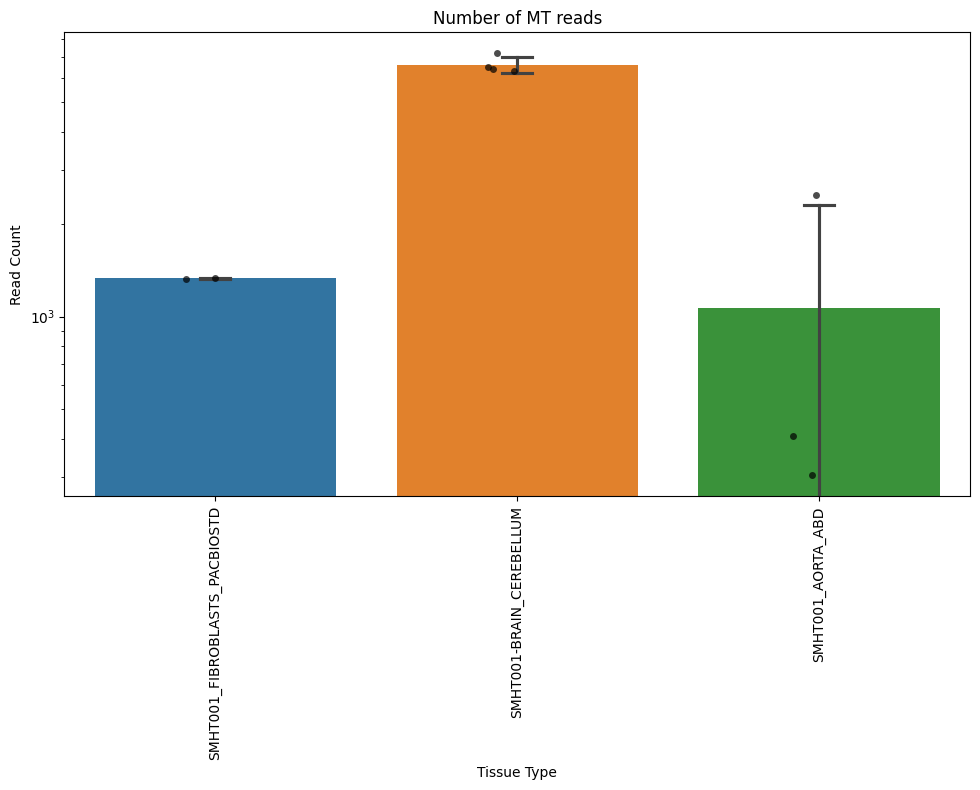

In [8]:
plt.figure(figsize=(10, 8))

sns.barplot(data=qc_df, x='Tissue', y='Read_Count', errorbar='sd', hue='Tissue', capsize=0.1)
sns.stripplot(data=qc_df, x='Tissue', y='Read_Count', color='black', jitter=True, alpha=0.7)

plt.title('Number of MT reads')
plt.xlabel('Tissue Type')
plt.ylabel('Read Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.yscale('log')
plt.show()

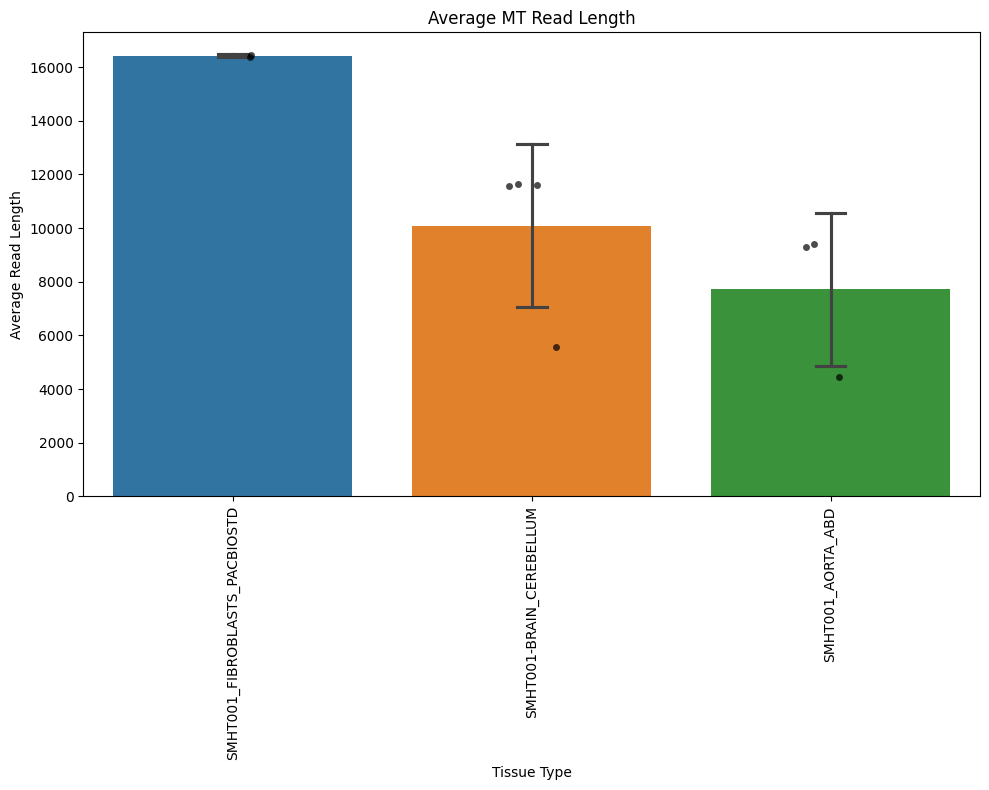

In [9]:
plt.figure(figsize=(10, 8))

sns.barplot(data=qc_df, x='Tissue', y='Average_Read_Length', errorbar='sd', hue='Tissue', capsize=0.1)
sns.stripplot(data=qc_df, x='Tissue', y='Average_Read_Length', color='black', jitter=True, alpha=0.7)

plt.title('Average MT Read Length')
plt.xlabel('Tissue Type')
plt.ylabel('Average Read Length')
plt.xticks(rotation=90)
plt.tight_layout()
#plt.yscale('log')
plt.show()

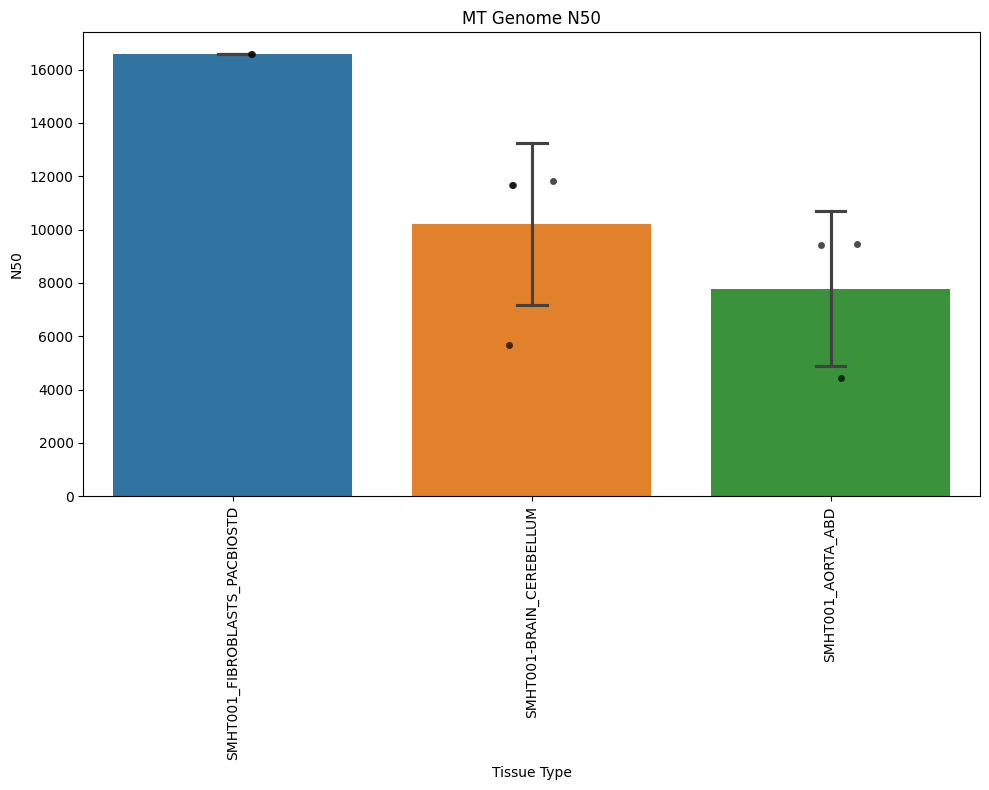

In [10]:
plt.figure(figsize=(10, 8))

sns.barplot(data=qc_df, x='Tissue', y='N50', errorbar='sd', hue='Tissue', capsize=0.1)
sns.stripplot(data=qc_df, x='Tissue', y='N50', color='black', jitter=True, alpha=0.7)

plt.title('MT Genome N50')
plt.xlabel('Tissue Type')
plt.ylabel('N50')
plt.xticks(rotation=90)
plt.tight_layout()
#plt.yscale('log')
plt.show()

In [11]:
## methylation plot

In [12]:
snv_vcf = pd.read_csv("/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/SMHT001/output/multisample_output/merged.mutserve.annotated.txt",sep='\t')

snv_vcf['ID'] = snv_vcf[['CHROM', 'POS', 'REF', 'ALT']].astype(str).agg('-'.join, axis=1)

snv_vcf


,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,PS30284.m84046_250525_075910_s3.bc2030.ft.MT.ref.filtered.bam,...,GB.Seqs.CR,Homoplasmy,Heteroplasmy,Disease,Status,References,Additional.Annotations,MitoTIP,Source,DiseaseVariantStatus
0,MT,73,MT-73-A-G,A,G,.,PASS,.,GT:AF:BQ:DP,1:1.00:38.99:643,...,42517.0,NaN,NaN,NaN,NaN,152,MT-HV2,NaN,variant_df,General Variant
1,MT,146,MT-146-T-C,T,C,.,PASS,.,GT:AF:BQ:DP,1:1.00:39.88:669,...,10127.0,+,-,Absence of Endometriosis,Reported,"1,112","MT-HV2,MT-OHR",NaN,"disease_df,variant_df",General Variant
2,MT,195,MT-195-T-C,T,C,.,PASS,.,GT:AF:BQ:DP,./.:.:.:.,...,9351.0,+,+,BD-associated / melanoma pts,Reported,"3,122","MT-HV2,MT-OHR",NaN,"disease_df,variant_df",General Variant
3,MT,214,MT-214-A-G,A,G,.,PASS,.,GT:AF:BQ:DP,0/1:0.03:39.47:671,...,299.0,NaN,NaN,NaN,NaN,17,"MT-HV2,MT-OHR,MT-CSB1",NaN,variant_df,General Variant
4,MT,263,MT-263-A-G,A,G,.,PASS,.,GT:AF:BQ:DP,1:0.999:39.48:678,...,45956.0,NaN,NaN,NaN,NaN,151,"MT-HV2,MT-OHR",NaN,variant_df,General Variant
5,MT,302,MT-302-A-C,A,C,.,PASS,.,GT:AF:BQ:DP,0/1:0.01:38.22:627,...,22.0,NaN,NaN,NaN,NaN,1,"MT-HV2,MT-OHR,MT-TFY,MT-CSB2",NaN,variant_df,General Variant
6,MT,310,MT-310-T-C,T,C,.,PASS,.,GT:AF:BQ:DP,1/0:0.824:38.26:615,...,23173.0,NaN,NaN,Possible protective factor for normal tension ...,Reported,"1,33","MT-HV2,MT-OHR,MT-CSB2",NaN,"disease_df,variant_df",General Variant
7,MT,556,MT-556-A-G,A,G,.,PASS,.,GT:AF:BQ:DP,0/1:0.01:38.29:667,...,2.0,NaN,NaN,NaN,NaN,1,"MT-HSP1,MT-HV3",NaN,variant_df,General Variant
8,MT,593,MT-593-T-C,T,C,.,PASS,.,GT:AF:BQ:DP,0/1:0.047:39.51:687,...,0.0,+,-,Nonsyndromic hearing loss / LHON,Reported,"7,17",NaN,0.80%,"disease_df,variant_df",General Variant
9,MT,750,MT-750-A-G,A,G,.,PASS,.,GT:AF:BQ:DP,1:1.00:37.86:642,...,0.0,NaN,NaN,NaN,NaN,113,NaN,NaN,variant_df,General Variant


In [13]:
filter_col = [col for col in snv_vcf if col.startswith('PS')]

df_long = pd.melt(
    snv_vcf[["POS", "ID"] + filter_col],
    id_vars=['POS', 'ID'],
    var_name='Sample',
    value_name='Value'
)

df_long['Sample'] = df_long['Sample'].str.removesuffix('.MT.ref.filtered.bam')

df_long

,POS,ID,Sample,Value
0,73,MT-73-A-G,PS30284.m84046_250525_075910_s3.bc2030.ft,1:1.00:38.99:643
1,146,MT-146-T-C,PS30284.m84046_250525_075910_s3.bc2030.ft,1:1.00:39.88:669
2,195,MT-195-T-C,PS30284.m84046_250525_075910_s3.bc2030.ft,./.:.:.:.
3,214,MT-214-A-G,PS30284.m84046_250525_075910_s3.bc2030.ft,0/1:0.03:39.47:671
4,263,MT-263-A-G,PS30284.m84046_250525_075910_s3.bc2030.ft,1:0.999:39.48:678
...,...,...,...,...
472,16224,MT-16224-T-C,PS30394.m84046_250427_102543_s4.bc2068.ft,1:1.00:39.71:142
473,16259,MT-16259-C-T,PS30394.m84046_250427_102543_s4.bc2068.ft,1:1.00:39.71:140
474,16260,MT-16260-C-T,PS30394.m84046_250427_102543_s4.bc2068.ft,./.:.:.:.
475,16311,MT-16311-T-C,PS30394.m84046_250427_102543_s4.bc2068.ft,1:1.00:39.08:138


In [17]:
snv_df = pd.merge(df_long, meta, on="Sample", how="inner")
snv_df[['GT', 'AF', 'BQ', 'DP']] = snv_df['Value'].str.split(':', expand=True)
#snv_df[['CHROM', 'POS', 'REF', 'ALT']] = snv_df['ID'].str.split('-', expand=True)
snv_df = snv_df.drop(columns=['Value'])
snv_df = snv_df[(snv_df['GT'] != '.') & (snv_df['GT'] != './.')]


def extract_element(row):
    if ',' in row['AF']:
        parts = row['AF'].split(',')
        if row['GT'] == '0/1':
            return parts[1]
        elif row['GT'] == '1/0':
            return parts[0]
    return row['AF']

snv_df['AF'] = snv_df.apply(extract_element, axis=1)
snv_df['AF'] = snv_df['AF'].astype(float)

snv_df

,POS,ID,Sample,Tissue,GT,AF,BQ,DP
0,73,MT-73-A-G,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,1,1.000,38.99,643
1,146,MT-146-T-C,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,1,1.000,39.88,669
3,214,MT-214-A-G,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,0/1,0.030,39.47,671
4,263,MT-263-A-G,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,1,0.999,39.48,678
5,302,MT-302-A-C,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,0/1,0.010,38.22,627
...,...,...,...,...,...,...,...,...
469,15326,MT-15326-A-G,PS30394.m84046_250427_102543_s4.bc2068.ft,SMHT001_AORTA_ABD,1,1.000,39.15,137
472,16224,MT-16224-T-C,PS30394.m84046_250427_102543_s4.bc2068.ft,SMHT001_AORTA_ABD,1,1.000,39.71,142
473,16259,MT-16259-C-T,PS30394.m84046_250427_102543_s4.bc2068.ft,SMHT001_AORTA_ABD,1,1.000,39.71,140
475,16311,MT-16311-T-C,PS30394.m84046_250427_102543_s4.bc2068.ft,SMHT001_AORTA_ABD,1,1.000,39.08,138


In [18]:
# Count unique samples per variant
variant_sample_counts = snv_df.groupby('ID')['Sample'].nunique().reset_index()
variant_sample_counts.columns = ['ID', 'SampleCount']

# Count unique samples per variant
variant_tissue_counts = snv_df.groupby('ID')['Tissue'].nunique().reset_index()
variant_tissue_counts.columns = ['ID', 'TissueCount']

merged_counts = pd.merge(variant_sample_counts, variant_tissue_counts, on="ID")
merged_counts['POS'] = merged_counts['ID'].str.split('-').str[1].astype(int)
merged_counts = merged_counts.sort_values(['TissueCount', 'SampleCount'])

merged_counts

#can i add avg heteroplasmy levels?


,ID,SampleCount,TissueCount,POS
1,MT-1097-G-A,1,1,1097
4,MT-11468-A-G,1,1,11468
17,MT-15756-G-A,1,1,15756
25,MT-195-T-C,1,1,195
30,MT-302-A-C,1,1,302
32,MT-3109-T-C,1,1,3109
36,MT-5231-G-C,1,1,5231
38,MT-556-A-G,1,1,556
49,MT-9252-T-C,1,1,9252
8,MT-12501-G-C,2,1,12501


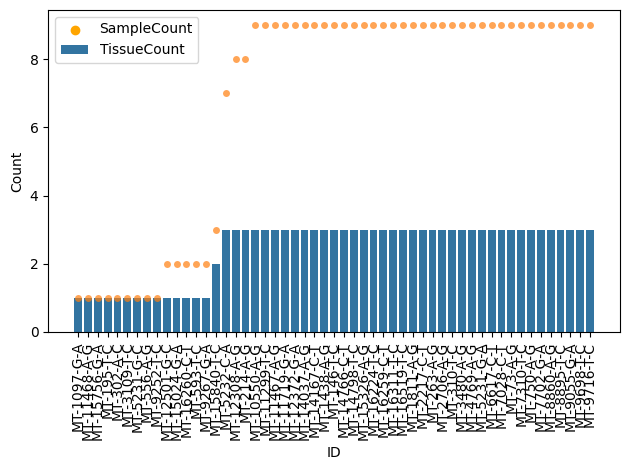

In [19]:
sns.barplot(data=merged_counts, y='TissueCount', x='ID', label='TissueCount')
sns.stripplot(data=merged_counts, x='ID', y='SampleCount', jitter=True, alpha=0.7)
plt.scatter([], [], color='orange', label='SampleCount')  # Empty but adds one legend entry
plt.xticks(rotation=90)
plt.tight_layout()
plt.ylabel('Count')
plt.legend()
plt.show()



In [20]:
# Filter variants with only one unique sample
singletons = merged_counts[merged_counts["TissueCount"] == 1]
singleton_df = snv_df[snv_df['ID'].isin(singletons['ID'])]
singleton_df


,POS,ID,Sample,Tissue,GT,AF,BQ,DP
5,302,MT-302-A-C,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,0/1,0.010,38.22,627
7,556,MT-556-A-G,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,0/1,0.010,38.29,667
8,593,MT-593-T-C,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,0/1,0.047,39.51,687
28,9252,MT-9252-T-C,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,0/1,0.014,39.47,703
29,9267,MT-9267-G-A,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,0/1,0.056,37.15,625
39,12501,MT-12501-G-C,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,0/1,0.085,39.41,708
44,15024,MT-15024-G-A,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,0/1,0.037,39.36,699
46,15756,MT-15756-G-A,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,0/1,0.009,39.50,698
50,16260,MT-16260-C-T,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,0/1,0.007,38.80,675
61,593,MT-593-T-C,PS30284.m84046_250525_100214_s4.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,0/1,0.055,39.63,691


In [21]:
## variants present in most tissues 
common_variants = merged_counts[merged_counts["TissueCount"] > 2]
common_variants_df = snv_df[snv_df['ID'].isin(common_variants['ID'])]
common_variants_df

,POS,ID,Sample,Tissue,GT,AF,BQ,DP
0,73,MT-73-A-G,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,1,1.000,38.99,643
1,146,MT-146-T-C,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,1,1.000,39.88,669
3,214,MT-214-A-G,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,0/1,0.030,39.47,671
4,263,MT-263-A-G,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,1,0.999,39.48,678
6,310,MT-310-T-C,PS30284.m84046_250525_075910_s3.bc2030.ft,SMHT001_FIBROBLASTS_PACBIOSTD,1/0,0.824,38.26,615
...,...,...,...,...,...,...,...,...
469,15326,MT-15326-A-G,PS30394.m84046_250427_102543_s4.bc2068.ft,SMHT001_AORTA_ABD,1,1.000,39.15,137
472,16224,MT-16224-T-C,PS30394.m84046_250427_102543_s4.bc2068.ft,SMHT001_AORTA_ABD,1,1.000,39.71,142
473,16259,MT-16259-C-T,PS30394.m84046_250427_102543_s4.bc2068.ft,SMHT001_AORTA_ABD,1,1.000,39.71,140
475,16311,MT-16311-T-C,PS30394.m84046_250427_102543_s4.bc2068.ft,SMHT001_AORTA_ABD,1,1.000,39.08,138


In [22]:
# Filter variants in multiple tissues but not all?
other_variants = merged_counts[(merged_counts["TissueCount"] > 1) & (merged_counts["TissueCount"] < 3)]
other_variants_df = snv_df[snv_df['ID'].isin(other_variants['ID'])]
other_variants_df

,POS,ID,Sample,Tissue,GT,AF,BQ,DP
153,15840,MT-15840-T-C,PS30385.m84046_250330_043334_s2.bc2065.ft,SMHT001-BRAIN_CEREBELLUM,0/1,0.007,39.72,1747
312,15840,MT-15840-T-C,PS30385.m84046_250427_143148_s2.bc2065.ft,SMHT001-BRAIN_CEREBELLUM,0/1,0.007,39.64,2572
365,15840,MT-15840-T-C,PS30394.m84046_250330_043334_s2.bc2068.ft,SMHT001_AORTA_ABD,0/1,0.012,39.73,489


/tmp/ipykernel_982921/1054756154.py:5: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.catplot(


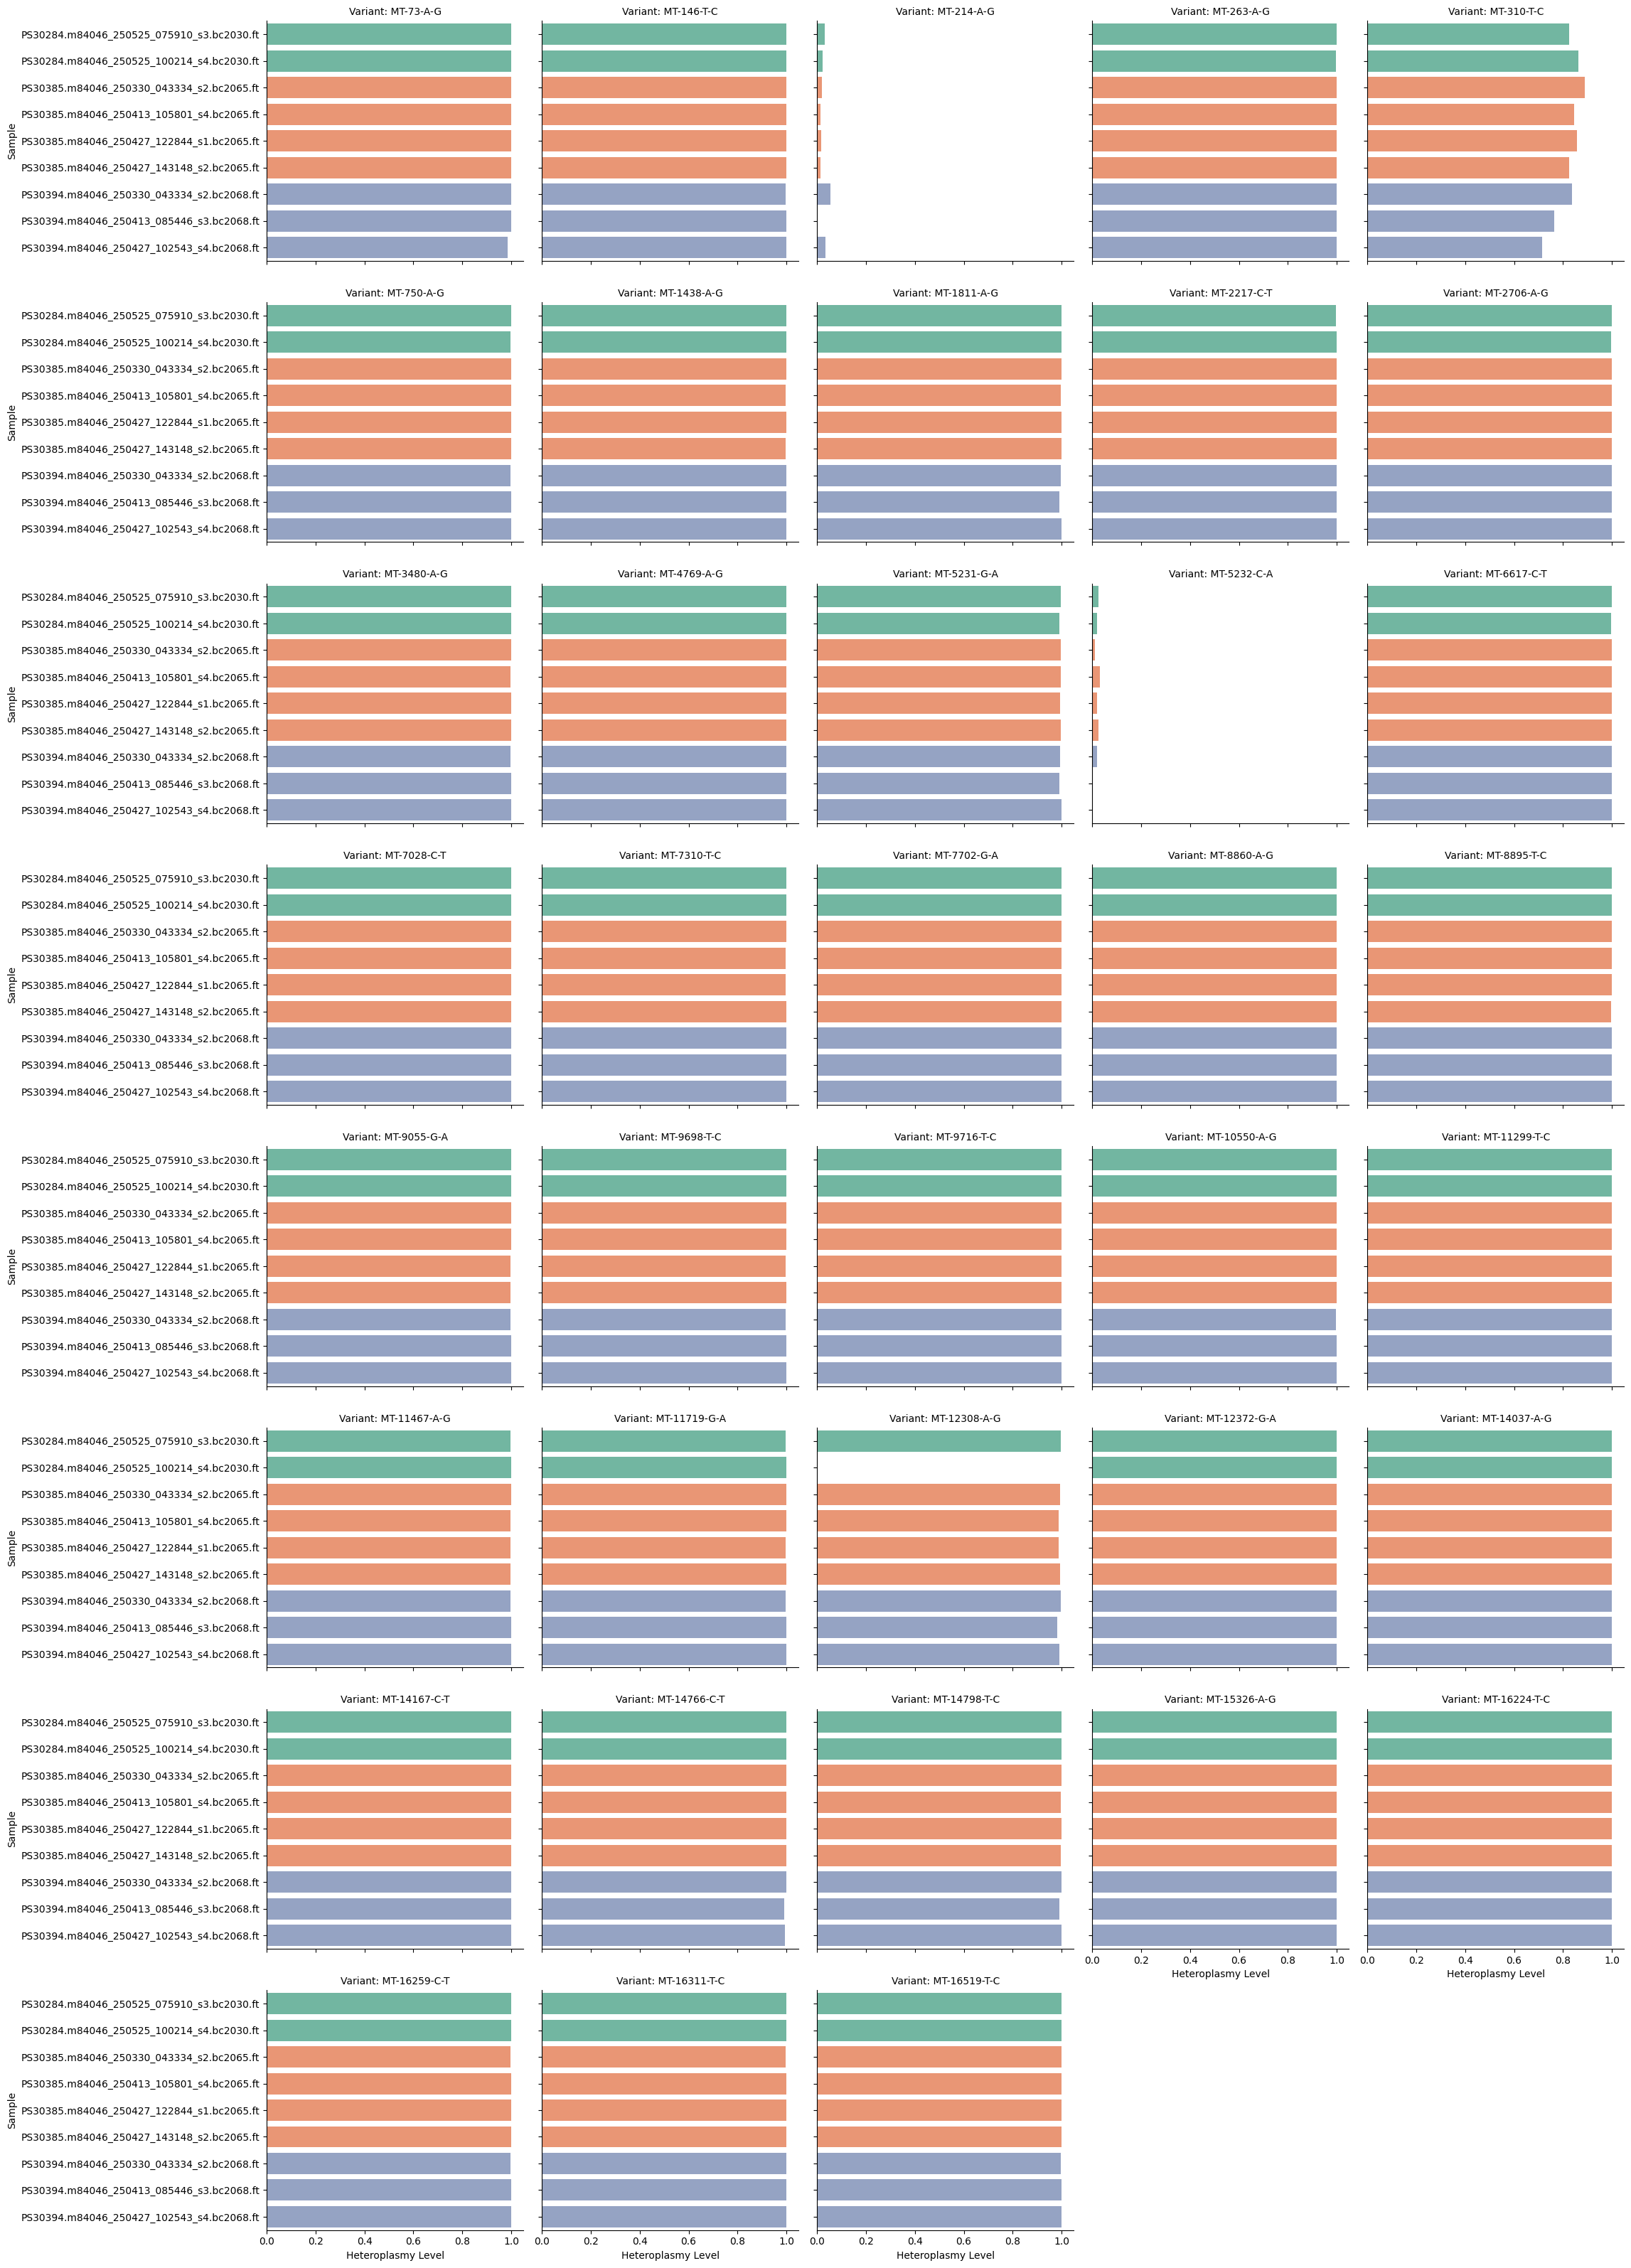

In [23]:
# Assuming df has columns: 'variant', 'sample', 'genotype' (heteroplasmy level)
variants = common_variants_df['ID'].unique()
all_samples = snv_df['Sample'].unique()

g = sns.catplot(
    data=common_variants_df,
    kind='bar',              # or 'point' if you want connected means
    x='AF',                    # Heteroplasmy level
    y='Sample',                # Sample names
    hue='Tissue',              # Color by tissue type
    col='ID',                  # One plot per variant
    col_wrap=5,
    height=4,
    sharex=True,
    palette=sns.color_palette("Set2", 10),            # Or another palette you like
)


g.set_titles(col_template='Variant: {col_name}')
g.set_xlabels('Heteroplasmy Level')
g.set_ylabels('Sample')

g._legend.remove()

# # Set x-axis limits for all plots to 0–1
# for ax in g.axes.flatten():
#     ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


/tmp/ipykernel_982921/2541284465.py:5: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  g = sns.catplot(


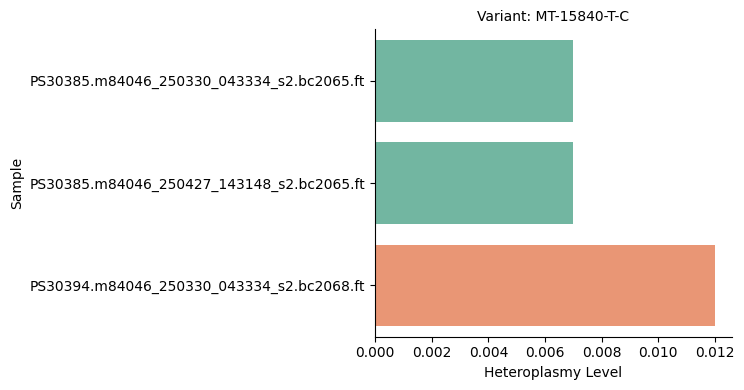

In [24]:
# Assuming df has columns: 'variant', 'sample', 'genotype' (heteroplasmy level)
variants = other_variants_df['ID'].unique()
all_samples = snv_df['Sample'].unique()

g = sns.catplot(
    data=other_variants_df,
    kind='bar',              # or 'point' if you want connected means
    x='AF',                    # Heteroplasmy level
    y='Sample',                # Sample names
    hue='Tissue',              # Color by tissue type
    col='ID',                  # One plot per variant
    col_wrap=5,
    height=4,
    sharex=True,
    palette=sns.color_palette("Set2"),            # Or another palette you like
)


g.set_titles(col_template='Variant: {col_name}')
g.set_xlabels('Heteroplasmy Level')
g.set_ylabels('Sample')

g._legend.remove()

# # Set x-axis limits for all plots to 0–1
# for ax in g.axes.flatten():
#     ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


/tmp/ipykernel_982921/1738490061.py:5: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  g = sns.catplot(


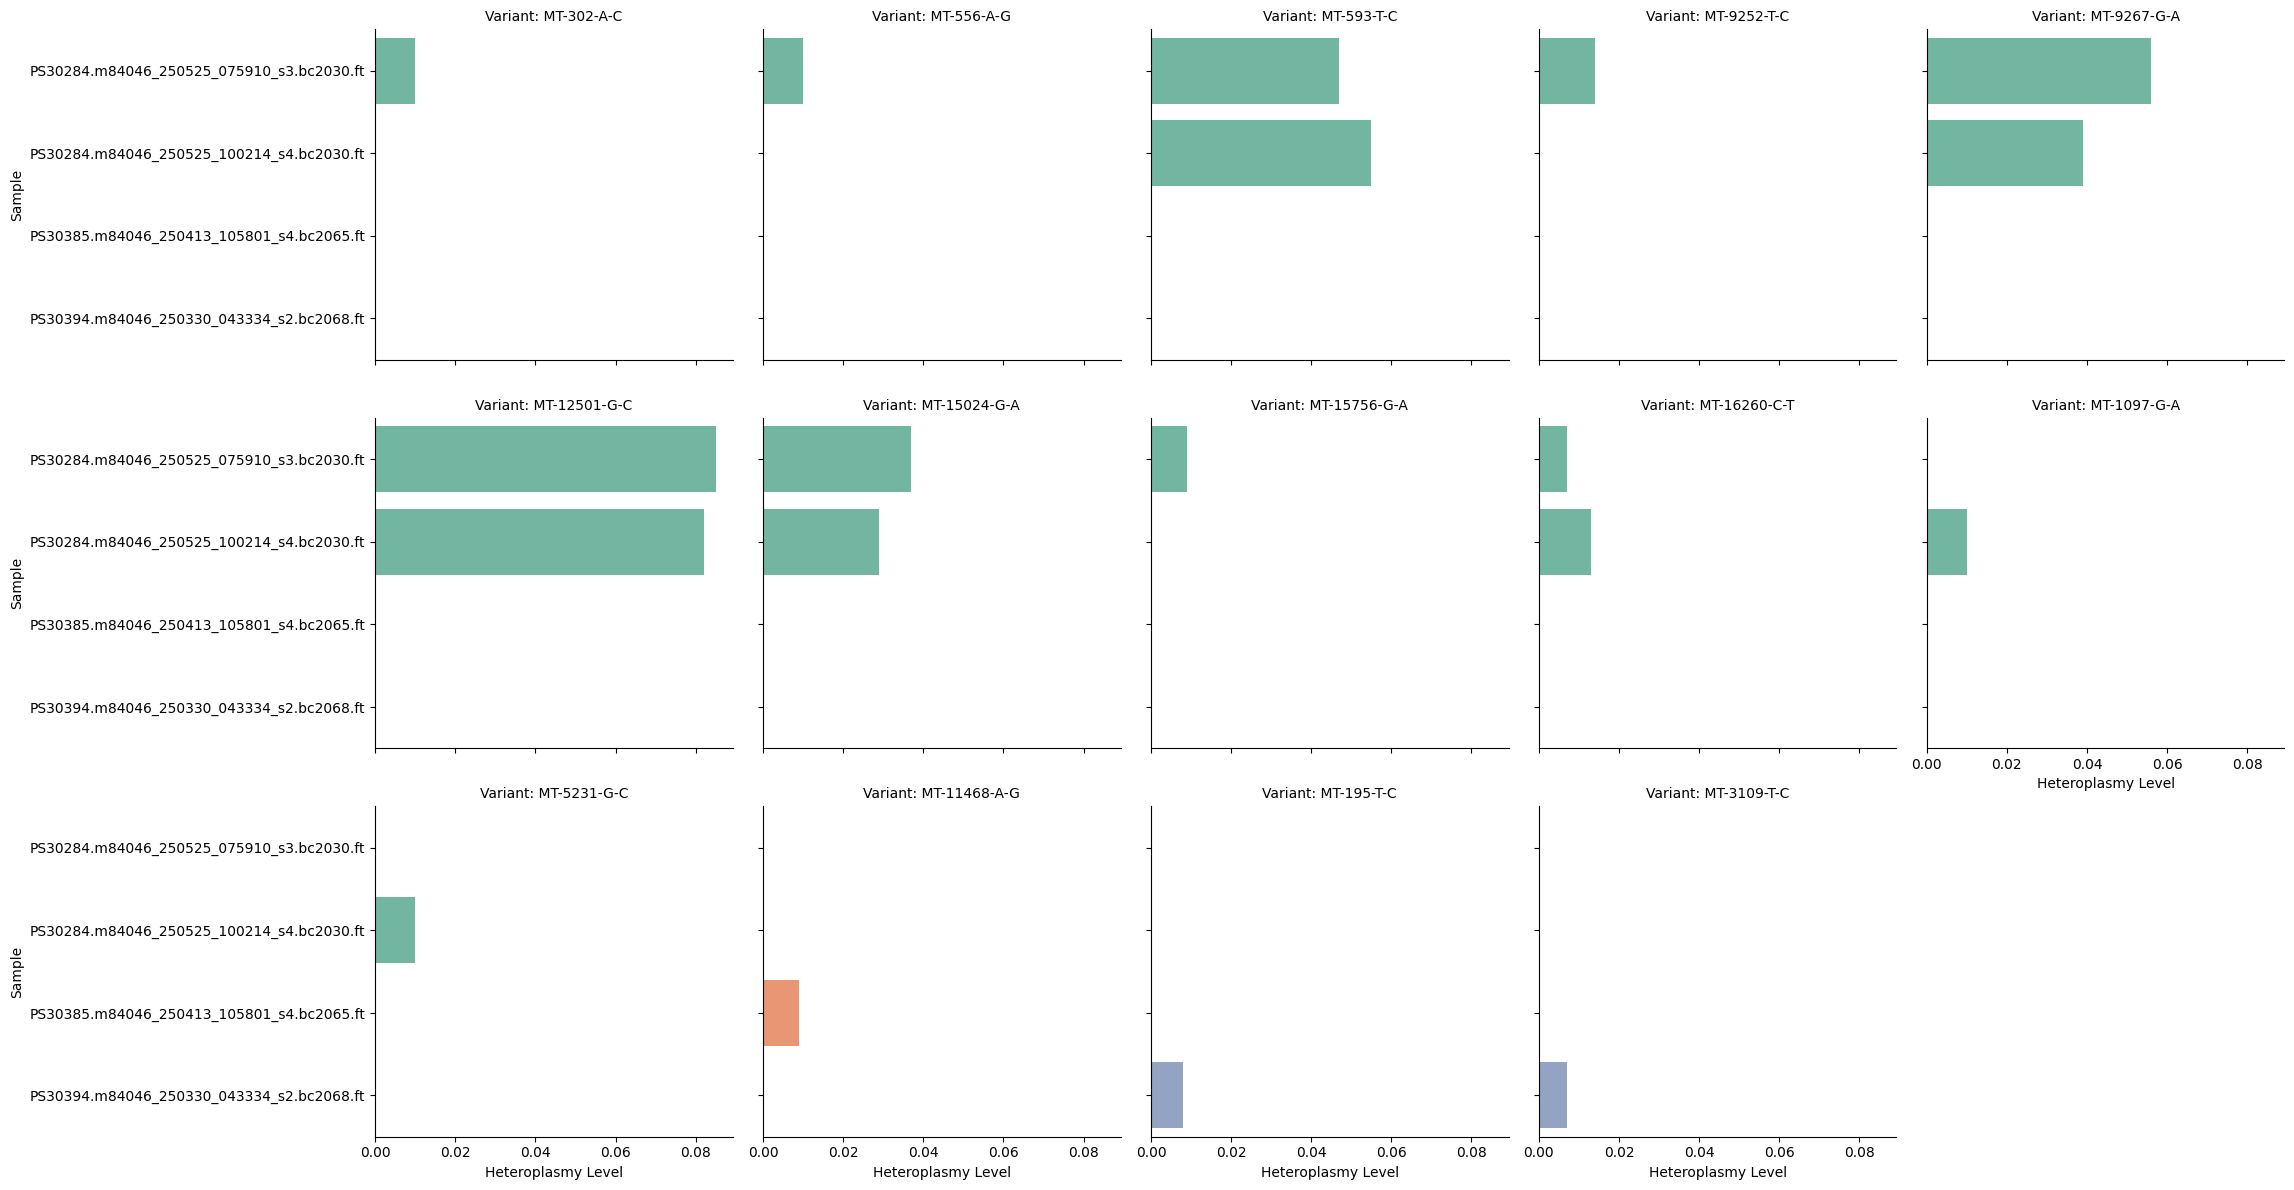

In [25]:
# Assuming df has columns: 'variant', 'sample', 'genotype' (heteroplasmy level)
variants = singleton_df['ID'].unique()
all_samples = snv_df['Sample'].unique()

g = sns.catplot(
    data=singleton_df,
    kind='bar',              # or 'point' if you want connected means
    x='AF',                    # Heteroplasmy level
    y='Sample',                # Sample names
    hue='Tissue',              # Color by tissue type
    col='ID',                  # One plot per variant
    col_wrap=5,
    height=4,
    sharex=True,
    palette=sns.color_palette("Set2"),            # Or another palette you like
)


g.set_titles(col_template='Variant: {col_name}')
g.set_xlabels('Heteroplasmy Level')
g.set_ylabels('Sample')

g._legend.remove()

# # Set x-axis limits for all plots to 0–1
# for ax in g.axes.flatten():
#     ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

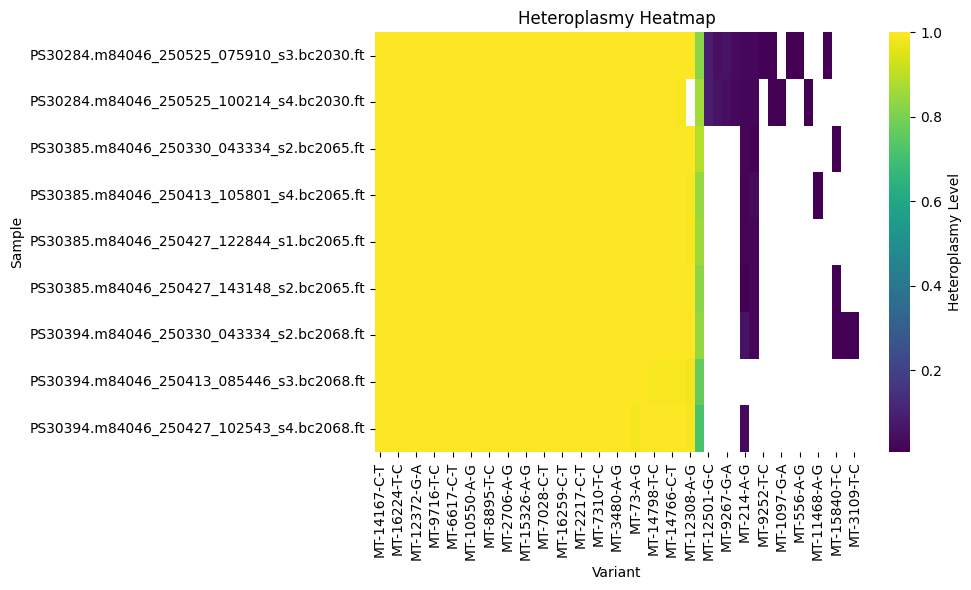

In [31]:

heatmap_data = snv_df.pivot(index='Sample', columns='ID', values='AF')

# Sort columns by highest average AF
column_order = heatmap_data.mean(axis=0).sort_values(ascending=False).index
heatmap_data = heatmap_data[column_order]


# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap="viridis", annot=False, fmt=".2f", cbar_kws={'label': 'Heteroplasmy Level'})

plt.title('Heteroplasmy Heatmap')
plt.xlabel('Variant')
plt.ylabel('Sample')
plt.tight_layout()
plt.show()


In [ ]:
smoothing_window=10

# Load minimod tsvs
input1=""

for 
df1 = pd.read_csv(input1, sep='\t').sort_values(['contig','start'])
df1['index'] = range(0, len(df1))
df1['perc'] = df1['freq']*100
df1['smoothed'] = df1['perc'].rolling(window=smoothing_window).mean()

plt.figure(figsize=(14, 4))
sns.lineplot(data=merged_df, x='index', y='smoothed', hue='sample', linewidth=1)
plt.xlabel("CpG Sites")
plt.ylabel("% methylation")
plt.title("Bar Plot to Smoothed Line")
plt.legend()
plt.ylim(0, 100)
plt.show()